In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df= pd.read_csv('Datasets/income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


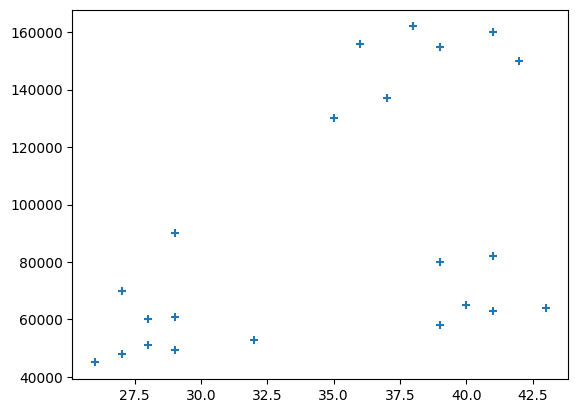

In [3]:
plt.scatter(df.Age,df['Income($)'],marker='+')
plt.show()

## obviously three clusters

In [4]:
km=KMeans(n_clusters=3)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [5]:
y_pred=km.fit_predict(df[['Age','Income($)']])
y_pred

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\user\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\user\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popena

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [6]:
df['cluster']=y_pred
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


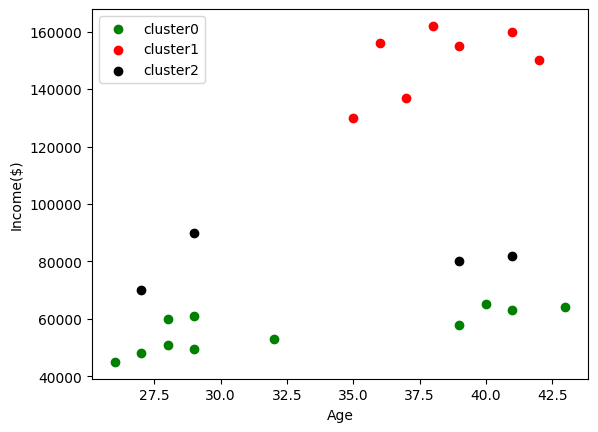

In [7]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green',label='cluster0')
plt.scatter(df2.Age,df2['Income($)'],color='red',label='cluster1')
plt.scatter(df3.Age,df3['Income($)'],color='black',label='cluster2')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()
plt.show()

#### we can see that there is a problem with the clustering my nigga , its because of the poorly scaled features

In [8]:
scaler=MinMaxScaler()
scaler.fit(df[['Income($)']])
df['Income($)']= scaler.transform(df[['Income($)']])
df

,Name,Age,Income($),cluster
0,Rob,27,0.213675,2
1,Michael,29,0.384615,2
2,Mohan,29,0.136752,0
3,Ismail,28,0.128205,0
4,Kory,42,0.897436,1
5,Gautam,39,0.940171,1
6,David,41,0.982906,1
7,Andrea,38,1.000000,1
8,Brad,36,0.948718,1
9,Angelina,35,0.726496,1


In [9]:
#scale age
scaler.fit(df[['Age']])
df['Age']= scaler.transform(df[['Age']])
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


In [10]:
km = KMeans(n_clusters=3)
y_pred =km.fit_predict(df[['Age','Income($)']]
                      )
df['cluster']=y_pred
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


In [11]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

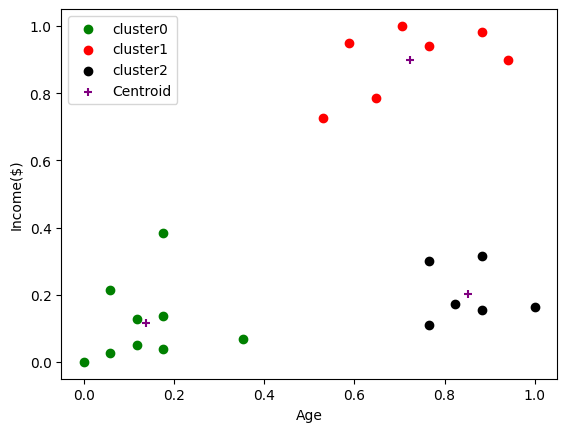

In [13]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green',label='cluster0')
plt.scatter(df2.Age,df2['Income($)'],color='red',label='cluster1')
plt.scatter(df3.Age,df3['Income($)'],color='black',label='cluster2')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='+',label='Centroid')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()
plt.show()

In [18]:
k_range=range(1,10)
sse=[]
for k in range(1,10):
    km=KMeans(n_clusters=k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)

In [17]:
sse

[5.434011511988179,
 2.3456144914725936,
 0.4750783498553096,
 0.3881529166478744,
 0.2621792762345213,
 0.2522119125653639,
 0.1685851223602976,
 0.15525565952103085,
 0.10629897421405132]

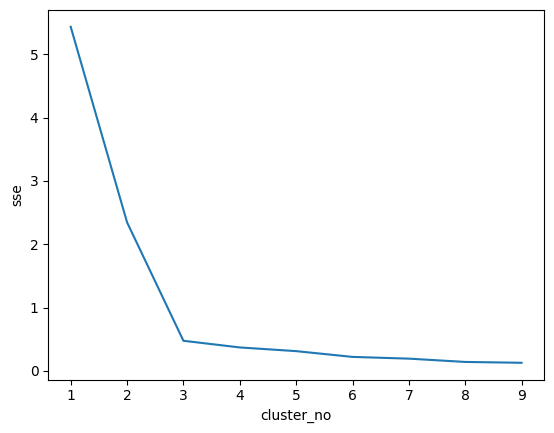

In [19]:
plt.xlabel('cluster_no')
plt.ylabel('sse')
plt.plot(k_range,sse)

## Ass
## Work on iris dataset

In [20]:
from sklearn.datasets import load_iris

In [21]:
iris=load_iris()

In [22]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [24]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [25]:
df['target']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


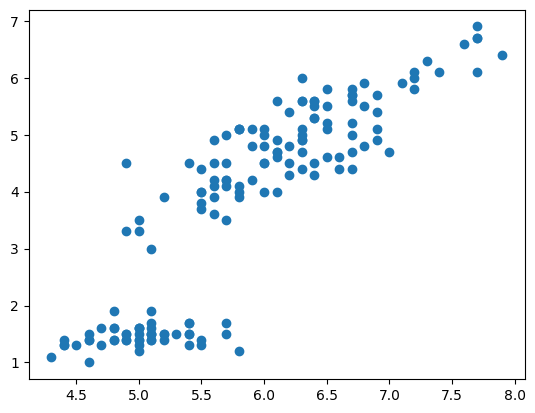

In [26]:
plt.scatter(df['sepal length (cm)'],df['petal length (cm)'])
plt.show()

In [31]:
#lets determine best k
k_range=range(1,30)
sse=[]
for k in range(1,30):
    km=KMeans(n_clusters=k)
    km.fit(df[['sepal length (cm)','petal length (cm)']])
    sse.append(km.inertia_)

In [32]:
sse

[566.4937333333334,
 112.99207175925926,
 109.23294345238095,
 34.925450356095524,
 25.63406450956451,
 22.14900506220506,
 20.39353866832093,
 17.547977931488806,
 14.613053328314198,
 11.972987407329512,
 10.657062473758122,
 9.067332425237597,
 8.566279755684928,
 8.074482972136222,
 7.4824347474163275,
 6.72937055999556,
 6.2434223970473965,
 6.723527825975194,
 5.745664502164501,
 5.349657786657786,
 4.679058150183149,
 4.23462121212121,
 4.26640873015873,
 3.9956749639249645,
 3.911229437229437,
 3.4888221500721515,
 3.3073264790764796,
 3.4887700208288455,
 3.348650793650793]

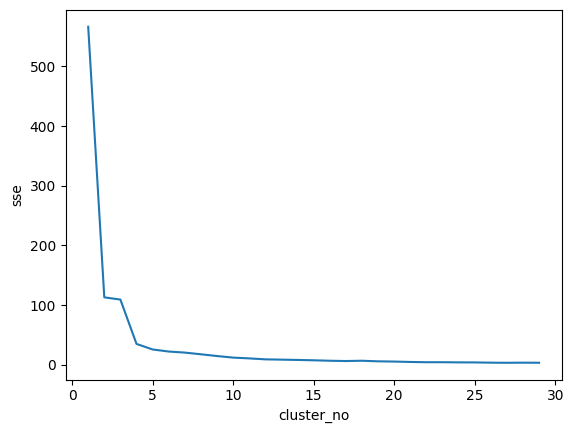

In [34]:
plt.xlabel('cluster_no')
plt.ylabel('sse')
plt.plot(k_range,sse)

In [42]:
km=KMeans(n_clusters=4)
y_pred=km.fit_predict(df[['sepal length (cm)','petal length (cm)']])
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 0, 3, 0, 3, 0, 3, 0, 0, 0, 0, 3, 0, 3,
       0, 0, 3, 0, 3, 0, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 3, 0, 0, 3, 3,
       0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 2, 3, 3, 2, 0, 2, 3, 2,
       3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 2, 3, 2, 3, 3, 2, 3, 3, 3, 2, 2, 2,
       3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3], dtype=int32)

In [43]:
df['cluster']=y_pred
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,3
146,6.3,2.5,5.0,1.9,2,3
147,6.5,3.0,5.2,2.0,2,3
148,6.2,3.4,5.4,2.3,2,3


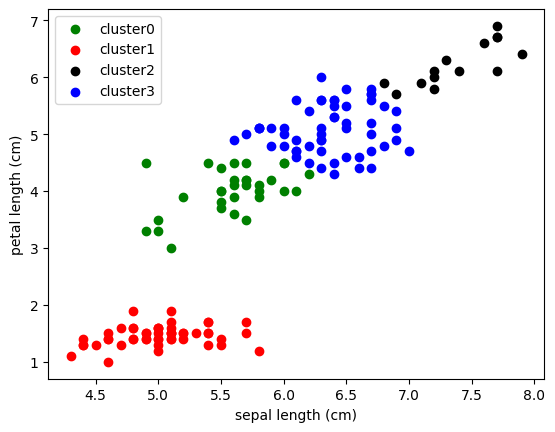

In [44]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]
df4=df[df.cluster==3]
#df5=df[df.cluster==4]
plt.scatter(df1['sepal length (cm)'],df1['petal length (cm)'],color='green',label='cluster0')
plt.scatter(df2['sepal length (cm)'],df2['petal length (cm)'],color='red',label='cluster1')
plt.scatter(df3['sepal length (cm)'],df3['petal length (cm)'],color='black',label='cluster2')
plt.scatter(df4['sepal length (cm)'],df4['petal length (cm)'],color='blue',label='cluster3')
#plt.scatter(df5['sepal length (cm)'],df5['petal length (cm)'],color='brown',label='cluster4')
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.legend()
plt.show()